In [44]:
from biom import load_table
from gemelli.rpca import rpca

# import the data table
table = load_table('data/skin_1975.biom')
# perform RPCA
ordination, distance = rpca(table.subsample(300, with_replacement=True))

/Users/tylermyers/anaconda3/envs/qiime2-shotgun-2024.2/lib/python3.8/site-packages/gemelli/preprocessing.py:425: RuntimeWarning: divide by zero encountered in log
  mat = np.log(matrix_closure(mat))


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
# from assets.plotting_helper import biplot
%matplotlib inline

# import the sample metadata
mf = pd.read_csv('data/skin_1975_map.txt',
                 sep='\t', index_col=0)#.drop(['#q2:types'], axis=0)
# import the taxonomy metadata
tf = pd.read_csv('data/skin_taxonomy.txt',
                 sep='\t', index_col=0)
# view
mf.head(2)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_14871/1496596478.py:9: DtypeWarning: Columns (124,384,841,844,968) have mixed types. Specify dtype option on import or set low_memory=False.
  mf = pd.read_csv('data/skin_1975_map.txt',


,achilles_tendinitis,acid_reflux,acne,acne_medication,acne_medication_otc,acute_kidney_failure,acute_liver_failure,add_0c,add_4c,add_5c,...,qiita_host_ethnicity_black_or_african_american,qiita_host_ethnicity_hispanic_or_latino,qiita_host_ethnicity_asian,qiita_host_ethnicity_american_indian_or_alaska_native,qiita_host_ethnicity_native_hawaiian_or_other_pacific_islander,qiita_host_ethnicity_other,qiita_host_ethnicity_combined,age_groups,X_sample_id,X_calour_original_abundance
#SampleID,,,,,,,,,,,,,,,,,,,,,
10317.000003638,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,white,50s,10317.000003638,36033
1841.F06478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,white,10s,1841.F06478,36089


In [46]:
# the sample loadings
spca_df = ordination.samples
spca_df.head(2)

,PC1,PC2,PC3
10317.000003638,-0.011653,-0.012928,-0.036467
1841.F06478,0.021381,-0.011066,-0.015680


In [47]:
fpca_df = ordination.features
fpca_df.head(2)

,PC1,PC2,PC3
TACGGAAGGTTCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCTGGAGATTAAGTGTGTTGTGAAATGTAGACGCTCAACGTCTGACTTG,0.000155,0.000771,0.00099
TACGGAGGGGGCTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCACGTAGGCGGCGATCTAAGTCAGAGGTGAAAGCCTGGAGCTCAACTCCAGAACTG,0.000031,0.000360,-0.00006


In [48]:
# merge the sample metadata and loadings
spca_df = pd.concat([spca_df, mf.reindex(spca_df.index)],
                    axis=1, sort=True)
spca_df.head(2)

,PC1,PC2,PC3,achilles_tendinitis,acid_reflux,acne,acne_medication,acne_medication_otc,acute_kidney_failure,acute_liver_failure,...,qiita_host_ethnicity_black_or_african_american,qiita_host_ethnicity_hispanic_or_latino,qiita_host_ethnicity_asian,qiita_host_ethnicity_american_indian_or_alaska_native,qiita_host_ethnicity_native_hawaiian_or_other_pacific_islander,qiita_host_ethnicity_other,qiita_host_ethnicity_combined,age_groups,X_sample_id,X_calour_original_abundance
10317.000002088,-0.025414,0.028207,0.010387,NaN,NaN,NaN,False,False,NaN,NaN,...,False,False,True,False,False,False,white,50s,10317.000002088,29821
10317.000002212,-0.025793,-0.026896,0.000127,NaN,NaN,NaN,False,False,NaN,NaN,...,False,False,True,False,False,False,white,60s,10317.000002212,5279


In [49]:
# merge the feature metadata and loadings
fpca_df = pd.concat([fpca_df, tf.reindex(fpca_df.index)],
                    axis=1, sort=True)
fpca_df.head(2)

,PC1,PC2,PC3,Taxon,Confidence
AACAGAGGATGCAAGCATTATCCAGAATTATTGGGCATAAAGTGTCTGTAGGTGGCTTTTCAAGTCCATTGTCAAATCCTAGGGCTCAACCCTGGATAGA,-0.000004,0.001011,0.000218,k__Bacteria; p__Cyanobacteria; c__Chloroplast;...,0.868494
AACAGAGGATGCAAGCGTTATCCGGAATGATTGGGCGTAAAGCGTCTGTAGGTGGCTTTTCAAGTCCGCCGTCAAATACCAGTGCTCAACCCTGGACAGG,0.000097,0.000359,0.000201,k__Bacteria; p__Cyanobacteria; c__Chloroplast;...,0.999983


In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def biplot(pc1, pc2, spca_df, fpca_df, label_column, ax):
    # Plot the samples
    ax.scatter(spca_df[pc1], spca_df[pc2], c='blue', label='Samples')
    
    # Add sample labels if label_column is provided
    if label_column in spca_df.columns:
        for i in range(len(spca_df)):
            ax.text(spca_df[pc1][i], spca_df[pc2][i], spca_df[label_column][i], color='blue', fontsize=9)

    # Plot the features
    for i in range(len(fpca_df)):
        ax.arrow(0, 0, fpca_df[pc1][i], fpca_df[pc2][i], color='red', alpha=0.5)
        ax.text(fpca_df[pc1][i] * 1.15, fpca_df[pc2][i] * 1.15, fpca_df['Taxon'][i], color='red', fontsize=9)

    ax.set_xlabel(pc1)
    ax.set_ylabel(pc2)
    ax.set_title(f'Biplot of {pc1} and {pc2}')
    ax.legend()

    return ax

In [51]:
# fig, ax = plt.subplots(1,1, figsize=(100, 100))

# # plot the biplot
# ax = biplot('PC1', 'PC2', spca_df,
#             fpca_df, 'host_subject_id', ax) #host subject id

# plt.show()

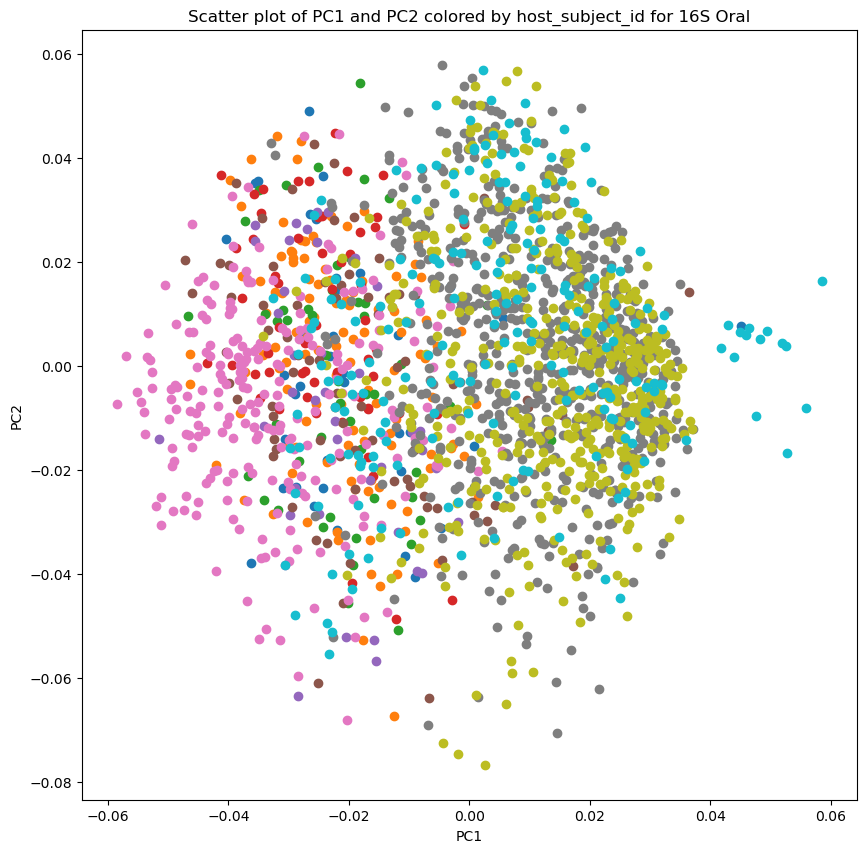

In [52]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Unique host_subject_ids for coloring
unique_ids = spca_df['host_subject_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_ids))
color_dict = {label: colors(i) for i, label in enumerate(unique_ids)}

# Plot the samples
for label in unique_ids:
    subset = spca_df[spca_df['host_subject_id'] == label]
    ax.scatter(subset['PC1'], subset['PC2'], label=label, color=color_dict[label])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Scatter plot of PC1 and PC2 colored by host_subject_id for 16S Oral')
# ax.legend()

plt.show()

In [53]:
from skbio.stats.distance import permanova

permanova(distance, mf['host_subject_id'])

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1975
number of groups                340
test statistic             9.006658
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object